# Lab 1 — What a graph can and cannot see

**Accompanies Lecture 1: Foundations of general topology**

This lab has three parts, all using nothing but plain graph theory (union-find,
connected components, cycle rank) — no simplicial complexes, no boundary
matrices, nothing from Lecture 1 yet.

1. **A circle, and a toy barcode** — watch a loop appear as a clean, small
   number as epsilon grows
2. **Two circles at different scales** — show that no single epsilon ever
   gives the right answer for both at once
3. **Sphere vs. ball, graph only** — show that a graph structurally cannot
   tell a hollow sphere from a solid ball apart, no matter how you tune epsilon

Each part ends in an `assert` cell. If your code is correct, the notebook
runs top to bottom with no errors.


In [1]:
import numpy as np

def cycle_rank_and_components(points, eps):
    """
    Build the eps-graph on `points` (edge between i,j iff distance <= eps),
    and return (C, cycle_rank) where:
      C          = number of connected components   (this is beta_0)
      cycle_rank = E - V + C                          (independent loops in
                   the GRAPH's 1-skeleton only -- not full simplicial beta_1,
                   see the lecture's caveat on this)
    This is plain union-find graph theory: no simplicial complex, no boundary
    matrices, nothing from Lecture 2 is needed here.
    """
    n = len(points)
    d = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=-1)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    E = 0
    for i in range(n):
        for j in range(i + 1, n):
            if d[i, j] <= eps:
                E += 1
                union(i, j)
    C = len(set(find(i) for i in range(n)))
    return C, E - n + C


In [ ]:
import matplotlib.pyplot as plt

def _eps_edges(points, eps):
    """Index pairs (i, j), i < j, with distance <= eps -- the edges of the eps-graph."""
    d = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=-1)
    i, j = np.triu_indices(len(points), k=1)
    mask = d[i, j] <= eps
    return i[mask], j[mask]

def plot_2d(points, eps=None, ax=None, title=None, **scatter_kw):
    """
    Scatter plot of a 2D point cloud (array of shape (n, 2)).
    If `eps` is given, also draw the edges of the eps-graph.
    Returns the matplotlib Axes.
    """
    points = np.asarray(points)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    if eps is not None:
        for i, j in zip(*_eps_edges(points, eps)):
            ax.plot(points[[i, j], 0], points[[i, j], 1],
                    color="gray", lw=0.8, alpha=0.6, zorder=1)
    scatter_kw.setdefault("s", 25)
    ax.scatter(points[:, 0], points[:, 1], zorder=2, **scatter_kw)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    if title is None and eps is not None:
        title = f"eps = {eps:g}"
    if title:
        ax.set_title(title)
    return ax

def plot_3d(points, eps=None, ax=None, title=None, **scatter_kw):
    """
    Scatter plot of a 3D point cloud (array of shape (n, 3)).
    If `eps` is given, also draw the edges of the eps-graph.
    Returns the matplotlib 3D Axes.
    """
    points = np.asarray(points)
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(projection="3d")
    if eps is not None:
        for i, j in zip(*_eps_edges(points, eps)):
            ax.plot(points[[i, j], 0], points[[i, j], 1], points[[i, j], 2],
                    color="gray", lw=0.6, alpha=0.5)
    scatter_kw.setdefault("s", 25)
    scatter_kw.setdefault("depthshade", True)
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], **scatter_kw)
    ax.set_box_aspect(np.ptp(points, axis=0))   # equal scaling on all axes
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    if title is None and eps is not None:
        title = f"eps = {eps:g}"
    if title:
        ax.set_title(title)
    return ax

## Part 1 — A circle, and a toy barcode

We reuse the circle-plus-centre-outlier point cloud from the lecture's opening
paradox. This time, instead of asking "which point is the outlier," we scan
epsilon and track **cycle rank** as a function of epsilon.

**Task**: generate the point cloud below (fixed seed, so everyone gets the
same data), scan epsilon over the given grid, and find:
- `birth`: the first epsilon at which cycle rank equals exactly 1
- `onset`: the first epsilon *after* birth at which cycle rank is no longer 1

**Important caveat**: in true persistent homology, a feature "dies" when a
2-simplex fills it in — a genuine topological event. Here we only have a
graph (no 2-simplices exist yet), so the plateau doesn't end because the loop
gets "filled in" — it ends because the centre point acquires a *second* spoke
to the ring, creating a shortcut cycle through the middle, which adds a
*second*, independent loop on top of the first. Cycle rank only ever goes up
from here. This is a toy preview of a barcode, not the real thing.


In [2]:
def make_ring_with_outlier(n=24, r=3.0, seed=7):
    rng = np.random.default_rng(seed)
    ang = np.linspace(0, 2*np.pi, n, endpoint=False) + rng.normal(0, 0.03, n)
    rad = r + rng.normal(0, 0.05, n)
    ring = np.stack([rad*np.cos(ang), rad*np.sin(ang)], axis=1)
    outlier = np.array([[0.0, 0.0]])
    return np.vstack([ring, outlier])

points_p1 = make_ring_with_outlier()
eps_grid_p1 = np.round(np.arange(0.05, 4.01, 0.01), 3)


In [3]:
# TODO: for each eps in eps_grid_p1, compute cycle rank via
# cycle_rank_and_components(points_p1, eps), storing the results in an array
# called cycle_ranks_p1 (same length as eps_grid_p1).
#
# Then find:
#   birth = the first eps where cycle_ranks_p1 == 1
#   onset = the first eps AFTER birth where cycle_ranks_p1 != 1

cycle_ranks_p1 = None  # TODO
birth = None           # TODO
onset = None            # TODO

print(f"birth: {birth:.2f}   onset of extra cycles: {onset:.2f}")


TypeError: unsupported format string passed to NoneType.__format__

ValueError: x, y, and format string must not be None

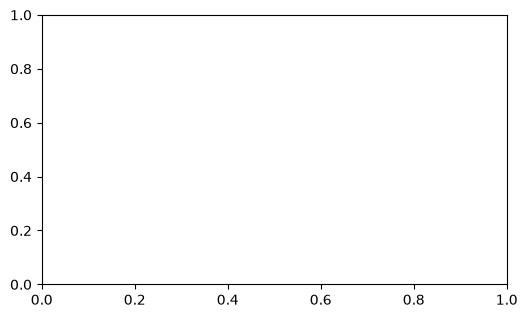

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3.5))
plt.step(eps_grid_p1, cycle_ranks_p1, where="post")
plt.axvspan(birth, onset, alpha=0.15, color="C1")
plt.xlabel("epsilon"); plt.ylabel("cycle rank")
plt.title("A toy barcode: one loop, born and then crowded")
plt.xlim(0, 3); plt.ylim(-0.5, 10)
plt.show()


In [5]:
# This cell checks your answer. It should run with no error.
assert abs(birth - 0.94) < 0.03, f"expected birth near 0.94, got {birth}"
assert abs(onset - 1.37) < 0.03, f"expected onset near 1.37, got {onset}"
print("Part 1 passed.")


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

## Part 2 — Two circles, two scales

A small ring (radius 1) and a large ring (radius 15), placed far enough apart
that points on one never come within epsilon of points on the other, for any
epsilon we will scan. Both rings have 10 points, evenly spaced.

**Task**: scan epsilon over a fine grid from just above 0 up to the safe
cross-ring limit given below, compute the combined cycle rank at each
epsilon, and check whether **any** epsilon gives combined cycle rank exactly
2 — i.e. whether there is a single threshold at which *both* rings show up as
clean, single loops at the same time.


In [ ]:
def regular_ngon(n, r, center):
    ang = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack([center[0]+r*np.cos(ang), center[1]+r*np.sin(ang)], axis=1)

small_ring = regular_ngon(10, 1.0,  center=(0, 0))
large_ring = regular_ngon(10, 15.0, center=(200, 0))
points_p2 = np.vstack([small_ring, large_ring])

cross_ring_gap = 200 - 1.0 - 15.0   # epsilon must stay well below this
eps_grid_p2 = np.round(np.arange(0.01, cross_ring_gap, 0.01), 2)


In [ ]:
# TODO: for each eps in eps_grid_p2, compute the combined cycle rank on
# points_p2. Collect every eps for which cycle rank == 2 into a list `hits`.

hits = None  # TODO

print(f"scanned {len(eps_grid_p2)} epsilon values")
print(f"number giving combined cycle_rank == 2: {len(hits)}")


In [ ]:
assert len(hits) == 0, (
    "Expected NO epsilon to give a clean count of 2 loops at once -- "
    f"but found {len(hits)} that did. Check your cycle-rank computation."
)
print("Part 2 passed: no single epsilon correctly resolves both rings at once.")


**Why this happens, precisely**: a regular n-gon of radius $r$ has nearest-
neighbour chord length $2r\sin(\pi/n)$ and next-nearest chord length
$2r\sin(2\pi/n)$ — its own "clean window" scales linearly with $r$. A $15\times$
radius ratio stretches the large ring's window $15\times$ wider and $15\times$
farther out than the small ring's, so the two windows never overlap. This
isn't a coincidence of these particular points — it's forced by the geometry,
which is exactly why a single global threshold can never work for data with
features at different scales.


## Part 3 — Sphere vs. ball, graph only

A hollow sphere (points on the surface only) and a solid ball (points filling
the whole volume), same point count. One encloses a genuine two-dimensional
void; the other doesn't.

**Task**: for each point cloud, find the first epsilon at which it becomes a
single connected component (`C == 1`), and report the cycle rank *at that
exact epsilon*. In Part 1, the analogous number was a clean, small, meaningful
integer (1). Check whether that happens here too.


In [ ]:
def sample_sphere_surface(n, seed):
    rng = np.random.default_rng(seed)
    v = rng.normal(size=(n, 3))
    return v / np.linalg.norm(v, axis=1, keepdims=True)

def sample_solid_ball(n, seed):
    rng = np.random.default_rng(seed)
    v = rng.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    r = rng.uniform(size=n) ** (1/3)
    return v * r[:, None]

n_p3 = 40
sphere_pts = sample_sphere_surface(n_p3, seed=300)
ball_pts   = sample_solid_ball(n_p3, seed=400)
eps_grid_p3 = np.round(np.arange(0.10, 2.01, 0.02), 3)


In [ ]:
# TODO: write first_connected_cycle_rank(points, eps_grid) -- it should scan
# eps_grid in order and return (eps, cycle_rank) for the FIRST eps at which
# the point cloud has exactly one connected component (C == 1).

def first_connected_cycle_rank(points, eps_grid):
    ...  # TODO

sphere_eps, sphere_cr = first_connected_cycle_rank(sphere_pts, eps_grid_p3)
ball_eps, ball_cr     = first_connected_cycle_rank(ball_pts, eps_grid_p3)

print(f"sphere: connects at eps={sphere_eps:.2f}, cycle_rank={sphere_cr}")
print(f"ball:   connects at eps={ball_eps:.2f}, cycle_rank={ball_cr}")


In [ ]:
assert sphere_cr > 20, f"expected sphere cycle rank at connection > 20, got {sphere_cr}"
assert ball_cr > 20, f"expected ball cycle rank at connection > 20, got {ball_cr}"
print("Part 3 passed: neither shape gives a small, clean, interpretable number.")


**The point**: in Part 1, the moment the graph became meaningfully
connected, cycle rank was exactly 1 — clean, small, interpretable, matching
the one real loop in the data. Here, by the time *either* shape is even
connected at all, cycle rank is already in the dozens, for both the hollow
sphere and the solid ball, with no plateau, no recognisable small integer
anywhere nearby. A graph is one-dimensional information — vertices and edges
only. It has no way to represent a two-dimensional membrane enclosing an
empty region, so there is nothing in this tool, at any epsilon, that could
possibly tell these two shapes apart. That gap is exactly what the rest of
this course is going to build: real simplicial complexes (Lecture 9) and
real boundary-rank machinery (Lecture 2, next) to compute $\beta_2$ on
purpose, not by accident of a 1-skeleton.


---
### That's the required part of this lab.

If there's time left in the session, your instructor may show you a couple
of extra things live — not required, nothing to submit:
- watching topological invariants stay constant under an actual homeomorphism
  (and change when the topology genuinely changes)
- a couple of *other* simple attempts at catching the sphere's void, and why
  each one fails for a different, interesting reason
